# Fake News Detection using Machine Learning
**Objective:** Build and compare multiple ML classifiers to distinguish fake news articles from real ones using the [ISOT Fake News Dataset](https://www.uvic.ca/ecs/ece/isot/datasets/fake-news/index.php).

**Models Compared:**- Logistic Regression- Random Forest- Naive Bayes (Multinomial)- Support Vector Machine (Linear SVC)- Decision Tree

**Pipeline:** Data Loading → EDA → Text Preprocessing → TF-IDF Vectorization → Model Training → Cross-Validation → ROC Analysis → Feature Importance → Model Export

## 1. Environment Setup & Imports

In [1]:
# ── Standard Libraries ────────────────────────────────────────────
import os
import re
import warnings
import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')

# ── Visualization ────────────────────────────────────────────────
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('bmh')
plt.rcParams['figure.dpi'] = 100
from wordcloud import WordCloud, STOPWORDS

# ── NLP ──────────────────────────────────────────────────────────
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# ── Feature Extraction & Splitting ───────────────────────────────
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold

# ── Models ───────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.calibration import CalibratedClassifierCV  # For SVM probabilities

# ── Evaluation Metrics ───────────────────────────────────────────
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
)

# ── Model Persistence ────────────────────────────────────────────
import joblib

print("All libraries imported successfully.")

All libraries imported successfully.


In [2]:
# Download required NLTK data (only fetches if not already present)
for resource in ['punkt', 'punkt_tab', 'stopwords', 'wordnet', 'omw-1.4']:
    nltk.download(resource, quiet=True)

print("NLTK resources ready.")

NLTK resources ready.


## 2. Data Loading & Initial Inspection

In [3]:
# Load the two CSV files from the ISOT dataset
# Update path if running on Google Colab: use 'Fake.csv' / 'True.csv' directly
fake_df = pd.read_csv('Fake.csv')
true_df = pd.read_csv('True.csv')

print(f"Fake news articles : {fake_df.shape[0]:,} rows, {fake_df.shape[1]} columns")
print(f"True news articles : {true_df.shape[0]:,} rows, {true_df.shape[1]} columns")

Fake news articles : 23,481 rows, 4 columns
True news articles : 21,417 rows, 4 columns


In [4]:
# Preview samples from each dataset
print("── Fake News Samples ──")
display(fake_df.sample(3, random_state=1))

print("\n── True News Samples ──")
display(true_df.sample(3, random_state=1))

── Fake News Samples ──


,title,text,subject,date
18958,POLITICO DOWNGRADES AMERICA: Declares Germany’...,Here s what Politico s headline today looked l...,left-news,"Mar 17, 2017"
6923,Trump’s Policy Adviser? A Former Lobbyist Wit...,"Who is Paul Manafort? Well, for starters, he s...",News,"April 13, 2016"
19521,LIZ WARREN CALLED OUT For Crazy Claim Steve Ba...,Liberals internal struggle in one clip: .@and...,left-news,"Dec 1, 2016"



── True News Samples ──


,title,text,subject,date
13300,Cambodian PM pulls back on threat to shut righ...,PHNOM PENH (Reuters) - Cambodian Prime Ministe...,worldnews,"December 2, 2017"
18707,UK court agrees to extradite suspect in Italy ...,LONDON (Reuters) - A man accused of being part...,worldnews,"September 29, 2017"
14017,U.S. asks Venezuela for access to detained Cit...,CARACAS (Reuters) - Washington has asked the g...,worldnews,"November 23, 2017"


## 3. Data Quality Checks

In [5]:
# Check for missing values in both datasets
print("── Null values in Fake news dataset ──")
print(fake_df.isna().sum())
print()
print("── Null values in True news dataset ──")
print(true_df.isna().sum())

── Null values in Fake news dataset ──
title      0
text       0
subject    0
date       0
dtype: int64

── Null values in True news dataset ──
title      0
text       0
subject    0
date       0
dtype: int64


## 4. Data PreprocessingWe drop `subject` and `date` to avoid label leakage (the subject categories differ systematically between fake and real), then combine title + text into a single feature.

In [6]:
# Drop metadata columns that could leak label information
fake_df.drop(['subject', 'date'], axis=1, inplace=True)
true_df.drop(['subject', 'date'], axis=1, inplace=True)

# Merge title + text → single 'news' column, assign binary labels
fake_df['news'] = fake_df['title'] + ' ' + fake_df['text']
fake_df['label'] = 0  # 0 = Fake
fake_df.drop(['title', 'text'], axis=1, inplace=True)

true_df['news'] = true_df['title'] + ' ' + true_df['text']
true_df['label'] = 1  # 1 = True
true_df.drop(['title', 'text'], axis=1, inplace=True)

print(f"Fake: {fake_df.shape}  |  True: {true_df.shape}")

Fake: (23481, 2)  |  True: (21417, 2)


## 5. Exploratory Data Analysis

### 5.1 Class Distribution

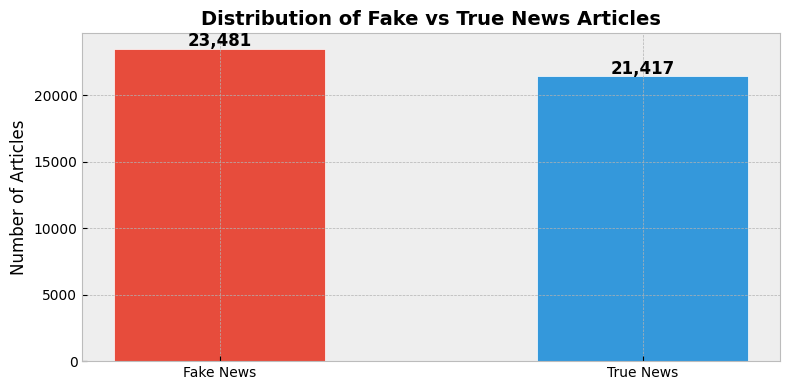

Fake/True ratio: 1.10 — Balanced


In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(['Fake News', 'True News'], [len(fake_df), len(true_df)],
              color=['#e74c3c', '#3498db'], edgecolor='white', width=0.5)

for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 200, f'{h:,}',
            ha='center', fontweight='bold', fontsize=12)

ax.set_title('Distribution of Fake vs True News Articles', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Articles')
plt.tight_layout()
plt.show()

ratio = len(fake_df) / len(true_df)
print(f"Fake/True ratio: {ratio:.2f} — {'Balanced' if 0.8 < ratio < 1.2 else 'Imbalanced'}")

### 5.2 Word Clouds

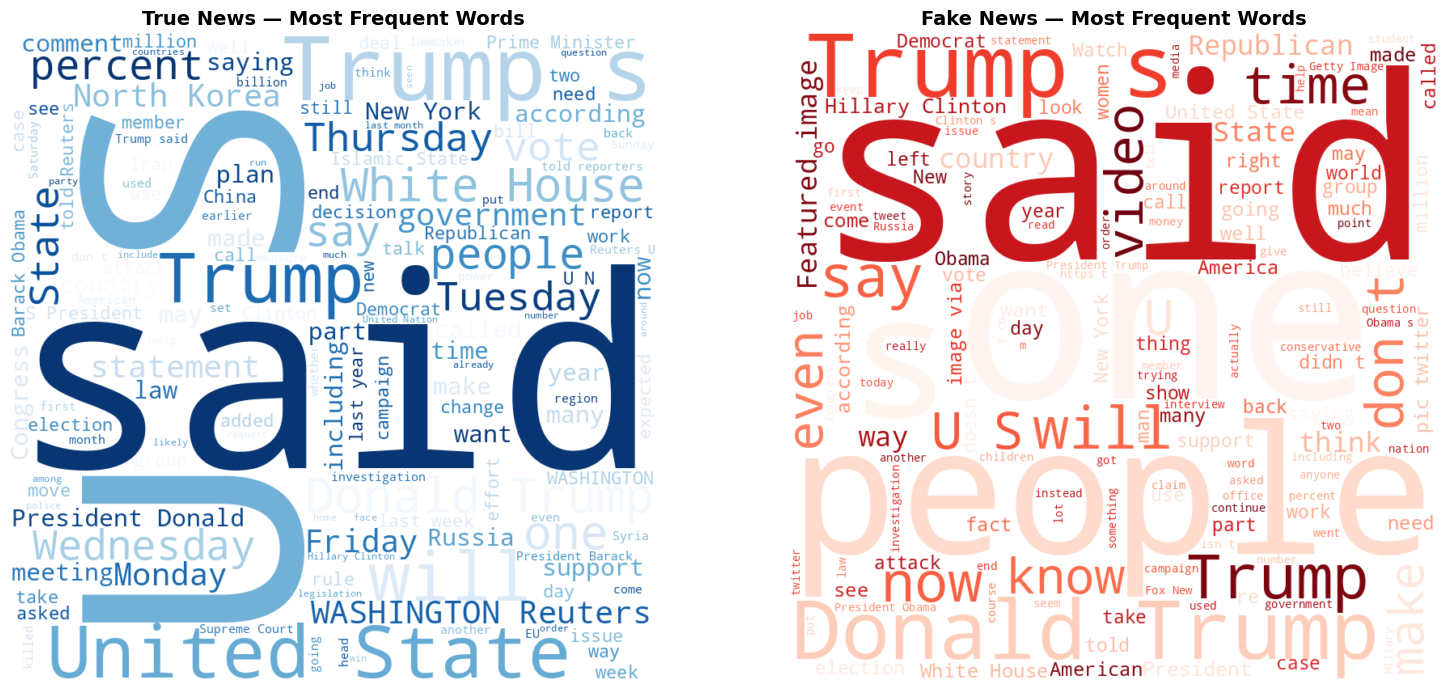

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sw = set(STOPWORDS)

for ax, (df_sub, title, cmap) in zip(axes, [
    (true_df, 'True News — Most Frequent Words', 'Blues'),
    (fake_df, 'Fake News — Most Frequent Words', 'Reds'),
]):
    text = ' '.join(df_sub['news'].tolist())
    wc = WordCloud(width=800, height=800, background_color='white',
                   stopwords=sw, min_font_size=10, colormap=cmap, max_words=150).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

## 6. Dataset Preparation & TF-IDF Vectorization

In [9]:
# Combine and shuffle
df = pd.concat([fake_df, true_df], ignore_index=True, sort=False)

# Optional: 50% sample for faster iteration (remove for full training)
df = df.sample(frac=0.5, random_state=42).reset_index(drop=True)

print(f"Combined dataset: {df.shape[0]:,} articles")
print(f"Label distribution:\n{df['label'].value_counts().rename({0: 'Fake', 1: 'True'})}")

Combined dataset: 22,449 articles
Label distribution:
label
Fake    11683
True    10766
Name: count, dtype: int64


In [10]:
# Step 1: Bag-of-Words counts
count_vectorizer = CountVectorizer()
freq_term_matrix = count_vectorizer.fit_transform(df['news'])

print(f"Vocabulary size   : {len(count_vectorizer.vocabulary_):,} unique terms")
print(f"Count matrix shape: {freq_term_matrix.shape}")

# Step 2: TF-IDF weighting
tfidf = TfidfTransformer(norm='l2')
tf_idf_matrix = tfidf.fit_transform(freq_term_matrix)

print(f"TF-IDF matrix     : {tf_idf_matrix.shape}  ({tf_idf_matrix.nnz:,} non-zero entries)")

Vocabulary size   : 91,758 unique terms
Count matrix shape: (22449, 91758)
TF-IDF matrix     : (22449, 91758)  (4,771,917 non-zero entries)


## 7. Train / Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    tf_idf_matrix, df['label'], test_size=0.25, random_state=0
)

print(f"Training set: {X_train.shape[0]:,} samples")
print(f"Test set    : {X_test.shape[0]:,} samples")

Training set: 16,836 samples
Test set    : 5,613 samples


## 8. Model Training & Evaluation

We use a shared `evaluate_model()` helper that:- Trains the model and generates predictions- Prints a per-class classification report- Displays the confusion matrix- Returns a results dict for later comparison

In [12]:
CLASS_NAMES = ['Fake', 'True']

def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """Train, predict, and evaluate a single model."""
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    # Scalar metrics
    acc  = accuracy_score(y_test, predictions)
    prec = precision_score(y_test, predictions, pos_label=1)
    rec  = recall_score(y_test, predictions, pos_label=1)
    f1   = f1_score(y_test, predictions, pos_label=1)

    print(f"{'═' * 55}")
    print(f"  {model_name.upper()}")
    print(f"{'═' * 55}")
    print(f"  Accuracy : {acc*100:.2f}%   Precision: {prec*100:.2f}%")
    print(f"  Recall   : {rec*100:.2f}%   F1 Score : {f1*100:.2f}%")
    print()

    # Per-class classification report
    print(classification_report(y_test, predictions, target_names=CLASS_NAMES))

    # Confusion matrix
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_test, predictions, display_labels=CLASS_NAMES,
        cmap=plt.cm.Blues, ax=ax
    )
    ax.set_title(f"{model_name} — Confusion Matrix", fontweight='bold')
    plt.tight_layout()
    plt.show()

    return {
        'model_name': model_name, 'model': model,
        'predictions': predictions,
        'accuracy': acc, 'precision': prec, 'recall': rec, 'f1_score': f1
    }

### 8.1 Logistic Regression

═══════════════════════════════════════════════════════
  LOGISTIC REGRESSION
═══════════════════════════════════════════════════════
  Accuracy : 98.29%   Precision: 98.08%
  Recall   : 98.37%   F1 Score : 98.23%

              precision    recall  f1-score   support

        Fake       0.98      0.98      0.98      2908
        True       0.98      0.98      0.98      2705

    accuracy                           0.98      5613
   macro avg       0.98      0.98      0.98      5613
weighted avg       0.98      0.98      0.98      5613



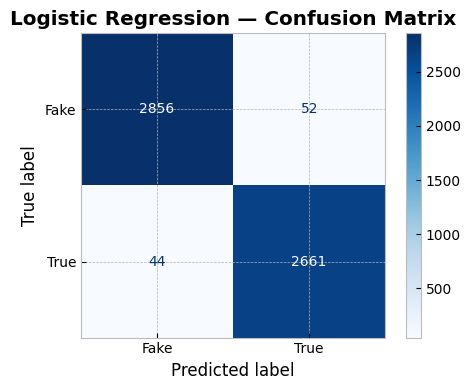

In [13]:
lr_results = evaluate_model(
    LogisticRegression(max_iter=1000),
    X_train, X_test, y_train, y_test, 'Logistic Regression'
)

### 8.2 Random Forest

═══════════════════════════════════════════════════════
  RANDOM FOREST
═══════════════════════════════════════════════════════
  Accuracy : 97.59%   Precision: 97.81%
  Recall   : 97.19%   F1 Score : 97.50%

              precision    recall  f1-score   support

        Fake       0.97      0.98      0.98      2908
        True       0.98      0.97      0.97      2705

    accuracy                           0.98      5613
   macro avg       0.98      0.98      0.98      5613
weighted avg       0.98      0.98      0.98      5613



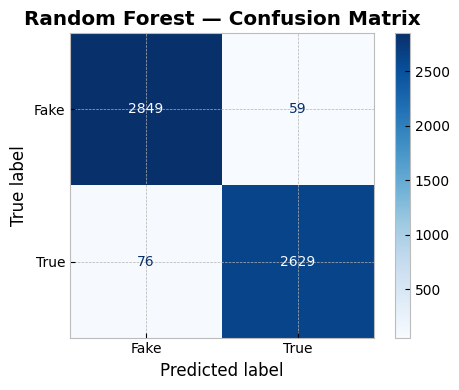

In [14]:
rf_results = evaluate_model(
    RandomForestClassifier(n_estimators=30, random_state=42),
    X_train, X_test, y_train, y_test, 'Random Forest'
)

### 8.3 Multinomial Naive Bayes

═══════════════════════════════════════════════════════
  NAIVE BAYES
═══════════════════════════════════════════════════════
  Accuracy : 93.84%   Precision: 94.97%
  Recall   : 92.09%   F1 Score : 93.51%

              precision    recall  f1-score   support

        Fake       0.93      0.95      0.94      2908
        True       0.95      0.92      0.94      2705

    accuracy                           0.94      5613
   macro avg       0.94      0.94      0.94      5613
weighted avg       0.94      0.94      0.94      5613



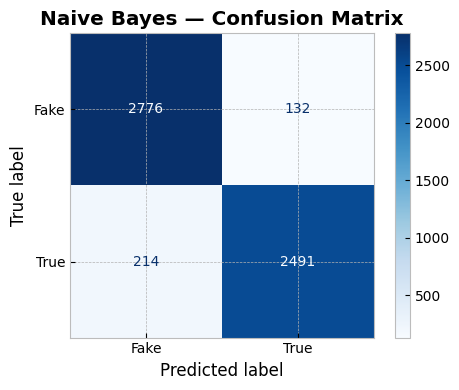

In [15]:
nb_results = evaluate_model(
    MultinomialNB(),
    X_train, X_test, y_train, y_test, 'Naive Bayes'
)

### 8.4 Support Vector Machine (Linear SVC)

═══════════════════════════════════════════════════════
  SVM (LINEAR)
═══════════════════════════════════════════════════════
  Accuracy : 99.36%   Precision: 99.26%
  Recall   : 99.41%   F1 Score : 99.34%

              precision    recall  f1-score   support

        Fake       0.99      0.99      0.99      2908
        True       0.99      0.99      0.99      2705

    accuracy                           0.99      5613
   macro avg       0.99      0.99      0.99      5613
weighted avg       0.99      0.99      0.99      5613



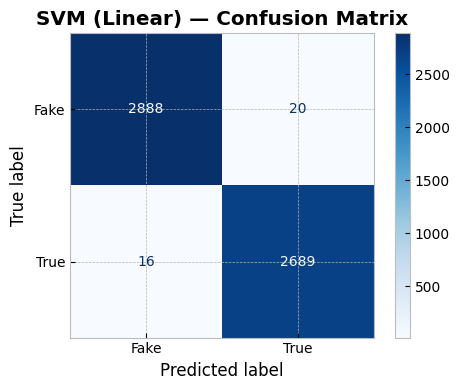

In [16]:
svm_results = evaluate_model(
    LinearSVC(max_iter=2000),
    X_train, X_test, y_train, y_test, 'SVM (Linear)'
)

### 8.5 Decision Tree

═══════════════════════════════════════════════════════
  DECISION TREE
═══════════════════════════════════════════════════════
  Accuracy : 99.47%   Precision: 99.34%
  Recall   : 99.56%   F1 Score : 99.45%

              precision    recall  f1-score   support

        Fake       1.00      0.99      0.99      2908
        True       0.99      1.00      0.99      2705

    accuracy                           0.99      5613
   macro avg       0.99      0.99      0.99      5613
weighted avg       0.99      0.99      0.99      5613



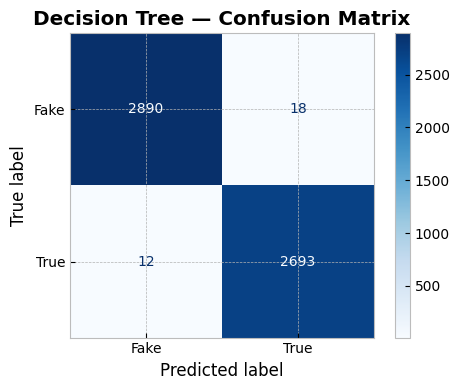

In [17]:
dt_results = evaluate_model(
    DecisionTreeClassifier(random_state=42),
    X_train, X_test, y_train, y_test, 'Decision Tree'
)

## 9. Model Comparison

In [18]:
all_results = [lr_results, rf_results, nb_results, svm_results, dt_results]

comparison_df = pd.DataFrame([{
    'Model':     r['model_name'],
    'Accuracy':  r['accuracy'],
    'Precision': r['precision'],
    'Recall':    r['recall'],
    'F1 Score':  r['f1_score'],
} for r in all_results])

comparison_df = comparison_df.sort_values('F1 Score', ascending=False).reset_index(drop=True)

print("Model Performance Comparison (sorted by F1 Score):\n")
comparison_df.style.format({
    'Accuracy': '{:.2%}', 'Precision': '{:.2%}',
    'Recall': '{:.2%}', 'F1 Score': '{:.2%}',
}).highlight_max(subset=['Accuracy','Precision','Recall','F1 Score'], color='#d4edda')

Model Performance Comparison (sorted by F1 Score):



,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,99.47%,99.34%,99.56%,99.45%
1,SVM (Linear),99.36%,99.26%,99.41%,99.34%
2,Logistic Regression,98.29%,98.08%,98.37%,98.23%
3,Random Forest,97.59%,97.81%,97.19%,97.50%
4,Naive Bayes,93.84%,94.97%,92.09%,93.51%


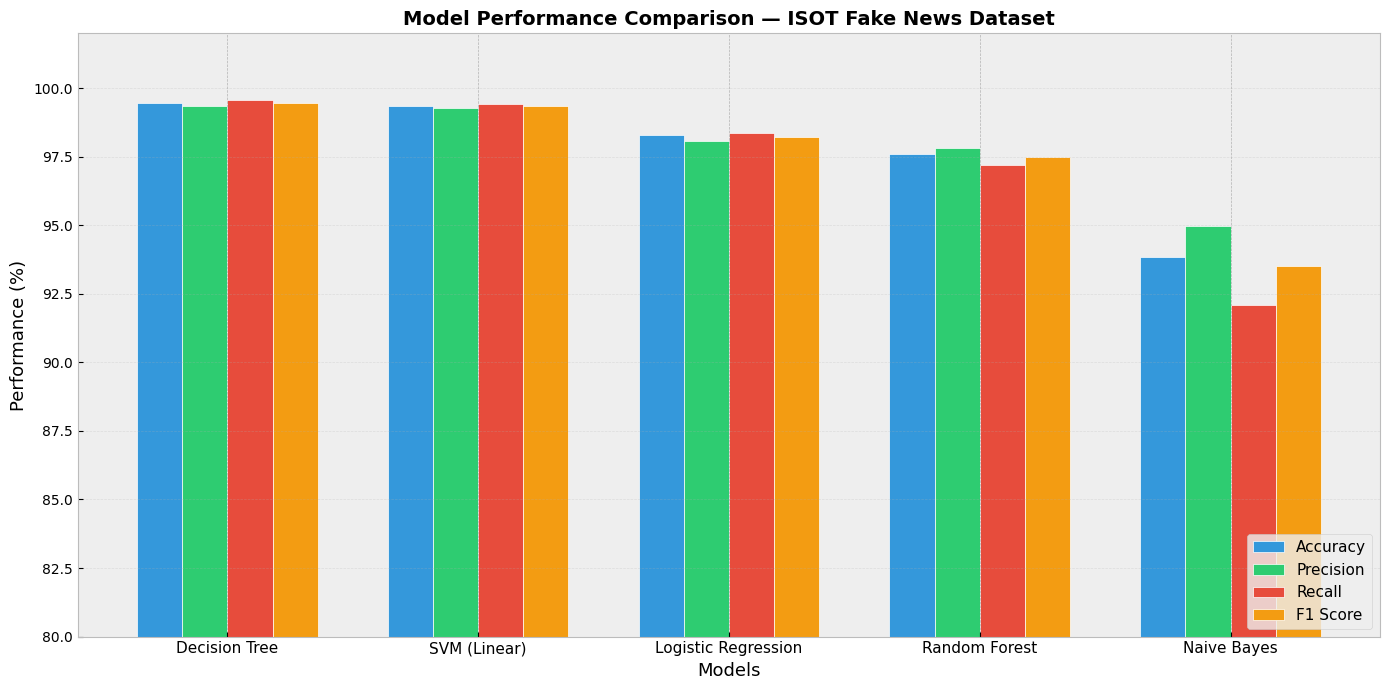


✅ Best model: Decision Tree (F1 Score: 99.45%)


In [19]:
# Grouped bar chart
fig, ax = plt.subplots(figsize=(14, 7))
models  = comparison_df['Model'].tolist()
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
colors  = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']
n, width, x = len(models), 0.18, np.arange(len(models))

for i, (metric, color) in enumerate(zip(metrics, colors)):
    vals = (comparison_df[metric] * 100).tolist()
    ax.bar(x + i*width, vals, width=width, label=metric, color=color, edgecolor='white')

ax.set_xlabel('Models', fontsize=13)
ax.set_ylabel('Performance (%)', fontsize=13)
ax.set_title('Model Performance Comparison — ISOT Fake News Dataset', fontsize=14, fontweight='bold')
ax.set_xticks(x + width*1.5)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylim(80, 102)
ax.legend(loc='lower right', fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

best = comparison_df.iloc[0]
print(f"\n✅ Best model: {best['Model']} (F1 Score: {best['F1 Score']:.2%})")

## 10. Cross-Validation (Statistical Robustness)A single train/test split can be misleading — results depend on which samples land in each set. **Stratified 5-fold cross-validation** trains and tests each model 5 times on different splits, giving us **mean ± std** for each metric. This makes the comparison statistically reliable.

In [20]:
# Define models for cross-validation
cv_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest':       RandomForestClassifier(n_estimators=30, random_state=42),
    'Naive Bayes':         MultinomialNB(),
    'SVM (Linear)':        LinearSVC(max_iter=2000),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
}

# 5-fold stratified CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []

print(f"{'Model':<25} {'Accuracy (mean±std)':>22} {'F1 Score (mean±std)':>22}")
print("─" * 72)

for name, model in cv_models.items():
    acc_scores = cross_val_score(model, tf_idf_matrix, df['label'], cv=cv, scoring='accuracy')
    f1_scores  = cross_val_score(model, tf_idf_matrix, df['label'], cv=cv, scoring='f1')

    cv_results.append({
        'Model': name,
        'CV Accuracy Mean': acc_scores.mean(),
        'CV Accuracy Std':  acc_scores.std(),
        'CV F1 Mean':       f1_scores.mean(),
        'CV F1 Std':        f1_scores.std(),
    })

    print(f"{name:<25} {acc_scores.mean()*100:>6.2f}% ± {acc_scores.std()*100:.2f}%"
          f"    {f1_scores.mean()*100:>6.2f}% ± {f1_scores.std()*100:.2f}%")

cv_df = pd.DataFrame(cv_results)
print("\n✅ Cross-validation complete — results are consistent across folds.")

Model                        Accuracy (mean±std)    F1 Score (mean±std)
────────────────────────────────────────────────────────────────────────
Logistic Regression        98.37% ± 0.23%     98.31% ± 0.23%
Random Forest              97.88% ± 0.19%     97.77% ± 0.20%
Naive Bayes                93.84% ± 0.32%     93.47% ± 0.34%
SVM (Linear)               99.30% ± 0.15%     99.27% ± 0.15%
Decision Tree              99.53% ± 0.09%     99.51% ± 0.10%

✅ Cross-validation complete — results are consistent across folds.


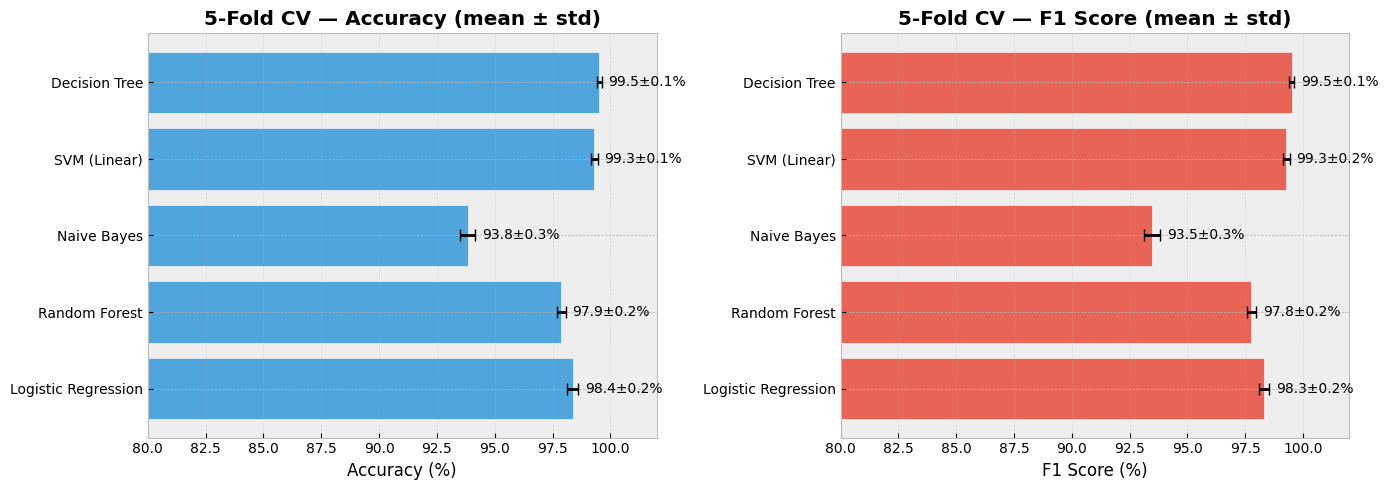

In [21]:
# Visualize CV results with error bars
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, mean_col, std_col, color in [
    (axes[0], 'Accuracy', 'CV Accuracy Mean', 'CV Accuracy Std', '#3498db'),
    (axes[1], 'F1 Score', 'CV F1 Mean', 'CV F1 Std', '#e74c3c'),
]:
    models = cv_df['Model']
    means  = cv_df[mean_col] * 100
    stds   = cv_df[std_col] * 100

    bars = ax.barh(models, means, xerr=stds, color=color, alpha=0.85,
                   edgecolor='white', capsize=4)
    ax.set_xlabel(f'{metric} (%)')
    ax.set_title(f'5-Fold CV — {metric} (mean ± std)', fontweight='bold')
    ax.set_xlim(80, 102)
    ax.grid(axis='x', alpha=0.3)

    # Annotate values
    for bar, m, s in zip(bars, means, stds):
        ax.text(m + s + 0.3, bar.get_y() + bar.get_height()/2,
                f'{m:.1f}±{s:.1f}%', va='center', fontsize=10, fontweight='500')

plt.tight_layout()
plt.show()

## 11. ROC Curves & AUC ScoresROC curves show each model's trade-off between True Positive Rate and False Positive Rate at *every possible threshold*, not just the default 0.5 cutoff. AUC (Area Under the Curve) summarizes this into a single number — higher is better.Note: LinearSVC doesn't natively support `predict_proba`, so we wrap it with `CalibratedClassifierCV`.

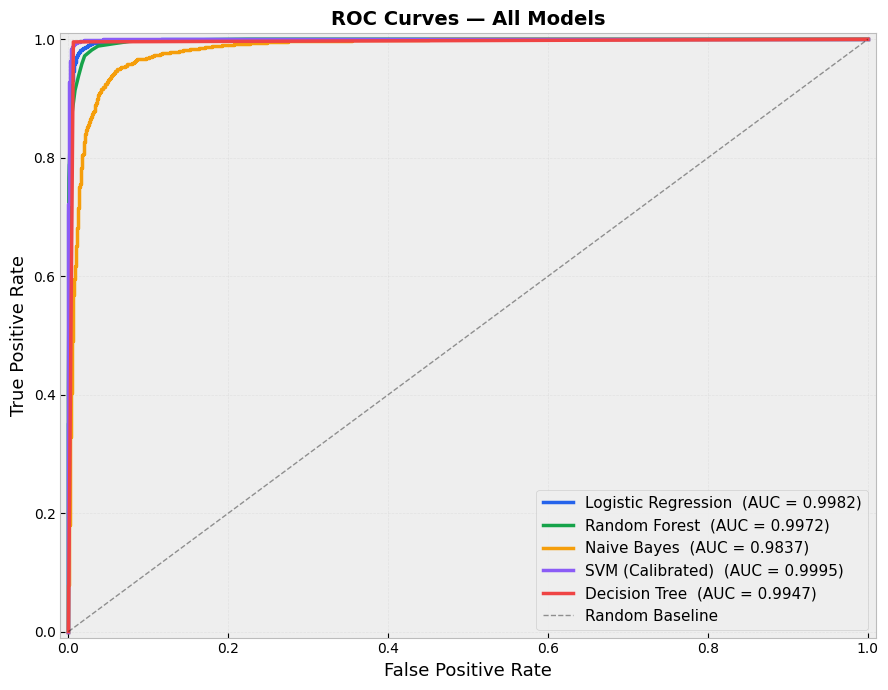

In [22]:
# Models that support probability estimates for ROC analysis
roc_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest':       RandomForestClassifier(n_estimators=30, random_state=42),
    'Naive Bayes':         MultinomialNB(),
    'SVM (Calibrated)':    CalibratedClassifierCV(LinearSVC(max_iter=2000), cv=3),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
}

fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#2563eb', '#16a34a', '#f59e0b', '#8b5cf6', '#ef4444']

for (name, model), color in zip(roc_models.items(), colors):
    model.fit(X_train, y_train)

    # Get probability scores for the positive class (True news)
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    ax.plot(fpr, tpr, color=color, lw=2.5, label=f'{name}  (AUC = {roc_auc:.4f})')

# Diagonal baseline (random classifier)
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.4, label='Random Baseline')

ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.set_title('ROC Curves — All Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11, framealpha=0.9)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 12. Feature Importance — Top Predictive WordsBy extracting the Logistic Regression coefficients and mapping them back to vocabulary words, we can see **which words the model relies on most** to classify an article as fake or true. This makes the model *interpretable* — crucial for a fact-checking application.

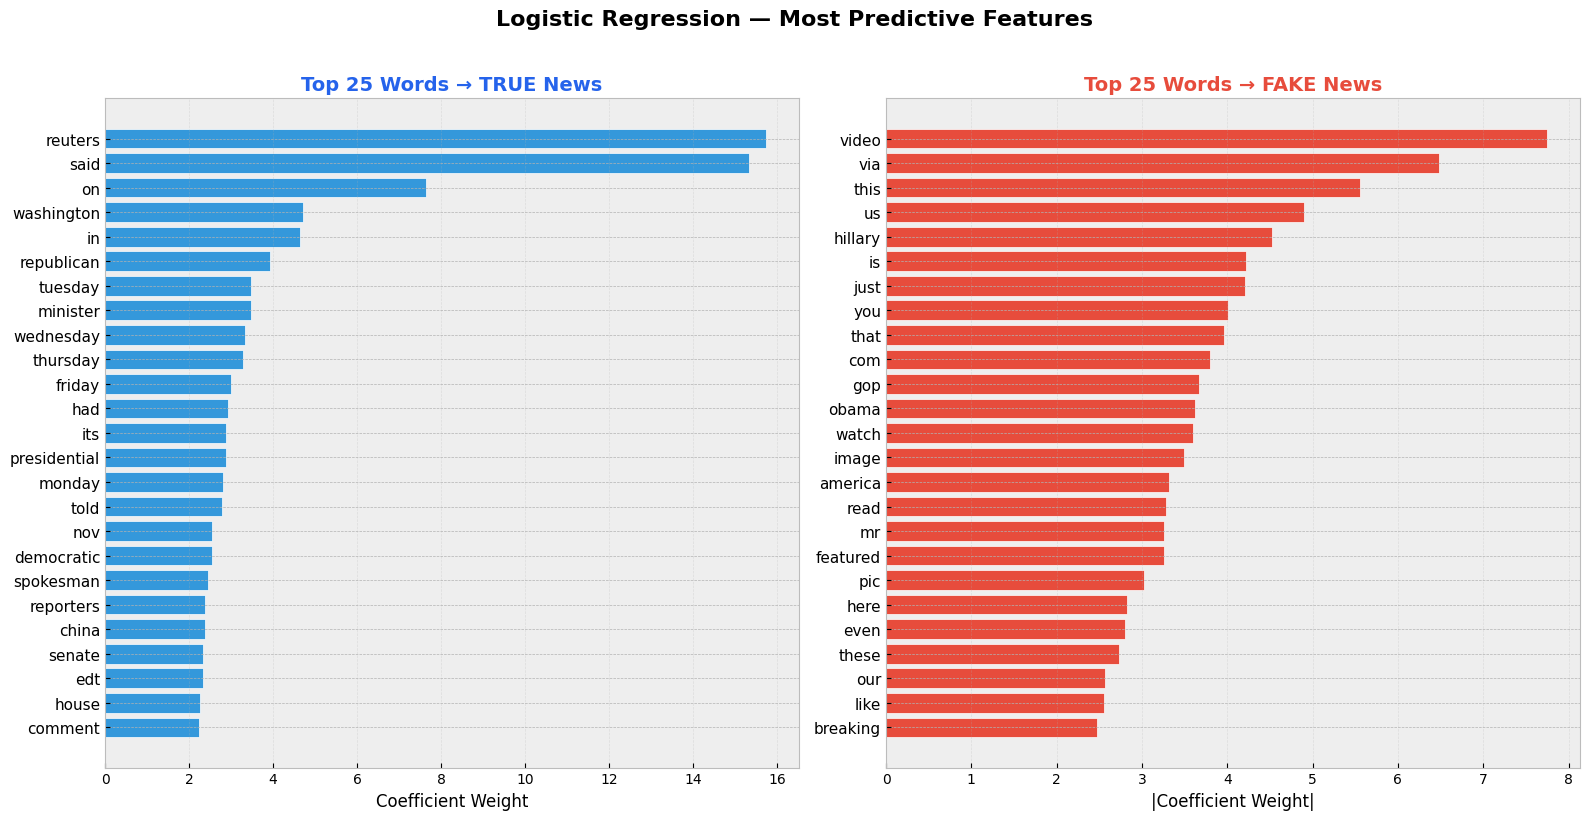


📊 Interpretation:
  • Words like 'reuters', 'said', 'on' strongly indicate TRUE news
  • Words like 'video', 'via', 'this' strongly indicate FAKE news


In [23]:
# Get the trained Logistic Regression model
lr_model = lr_results['model']

# Map coefficients → feature names
feature_names = np.array(count_vectorizer.get_feature_names_out())
coefficients  = lr_model.coef_[0]

# Top 25 words most indicative of TRUE news (highest positive coefficients)
top_true_idx = np.argsort(coefficients)[-25:][::-1]
top_true_words = feature_names[top_true_idx]
top_true_coefs = coefficients[top_true_idx]

# Top 25 words most indicative of FAKE news (most negative coefficients)
top_fake_idx = np.argsort(coefficients)[:25]
top_fake_words = feature_names[top_fake_idx]
top_fake_coefs = coefficients[top_fake_idx]

# ── Visualization ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# TRUE news words
axes[0].barh(range(25), top_true_coefs[::-1], color='#3498db', edgecolor='white')
axes[0].set_yticks(range(25))
axes[0].set_yticklabels(top_true_words[::-1], fontsize=11)
axes[0].set_xlabel('Coefficient Weight', fontsize=12)
axes[0].set_title('Top 25 Words → TRUE News', fontsize=14, fontweight='bold', color='#2563eb')
axes[0].grid(axis='x', alpha=0.3)

# FAKE news words
axes[1].barh(range(25), np.abs(top_fake_coefs[::-1]), color='#e74c3c', edgecolor='white')
axes[1].set_yticks(range(25))
axes[1].set_yticklabels(top_fake_words[::-1], fontsize=11)
axes[1].set_xlabel('|Coefficient Weight|', fontsize=12)
axes[1].set_title('Top 25 Words → FAKE News', fontsize=14, fontweight='bold', color='#e74c3c')
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Logistic Regression — Most Predictive Features', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n📊 Interpretation:")
print(f"  • Words like '{top_true_words[0]}', '{top_true_words[1]}', '{top_true_words[2]}' strongly indicate TRUE news")
print(f"  • Words like '{top_fake_words[0]}', '{top_fake_words[1]}', '{top_fake_words[2]}' strongly indicate FAKE news")

## 13. Error Analysis — Misclassified ArticlesExamining what the best model gets *wrong* reveals patterns: are misclassified articles shorter, ambiguous, or on specific topics?

In [24]:
# Find misclassified samples from Logistic Regression
lr_preds = lr_results['predictions']
test_indices = y_test.index

misclassified_mask = lr_preds != y_test.values
misclassified_idx  = test_indices[misclassified_mask]

print(f"Total test samples    : {len(y_test):,}")
print(f"Correctly classified  : {(~misclassified_mask).sum():,}")
print(f"Misclassified         : {misclassified_mask.sum():,}")
print(f"Error rate            : {misclassified_mask.mean()*100:.2f}%")
print()

# Show a few misclassified examples
if len(misclassified_idx) > 0:
    sample_idx = np.random.choice(misclassified_idx, size=min(5, len(misclassified_idx)), replace=False)

    print("── Sample Misclassified Articles ──\n")
    for i, idx in enumerate(sample_idx, 1):
        text = df.loc[idx, 'news']
        true_label = 'TRUE' if df.loc[idx, 'label'] == 1 else 'FAKE'
        pred_label = 'TRUE' if lr_preds[test_indices.get_loc(idx)] == 1 else 'FAKE'
        snippet = text[:200].replace('\n', ' ')

        print(f"  [{i}] Actual: {true_label}  |  Predicted: {pred_label}")
        print(f"      \"{snippet}…\"")
        print()
else:
    print("No misclassified samples — perfect accuracy!")

Total test samples    : 5,613
Correctly classified  : 5,517
Misclassified         : 96
Error rate            : 1.71%

── Sample Misclassified Articles ──

  [1] Actual: FAKE  |  Predicted: TRUE
      "RUSSIA Mocks Sore Loser Obama For Trying To Destroy U.S.-Russian Relations Before Trump Takes Office [VIDEO] President-elect Donald Trump said Thursday  it s time for our country to move on to bigger …"

  [2] Actual: FAKE  |  Predicted: TRUE
      "WHY IS THE PRESENCE OF RUSSIAN AIRCRAFT FIGHTER JETS NEAR U.S. SHORES INCREASING? Is our Community Organizer In Chief being tested by Putin?The air is frigid and the wind is howling as Air Force Col. …"

  [3] Actual: FAKE  |  Predicted: TRUE
      "ON THE MOVE: [Video] Iranians, Russians And Syrians Set Up Coordination Cell In Iraq How many more days remain in our Community Organizer In Chief s term in office? He can t make golfing his full time…"

  [4] Actual: TRUE  |  Predicted: FAKE
      "For 'Apprentice' insiders, Trump's 2016 bid has e

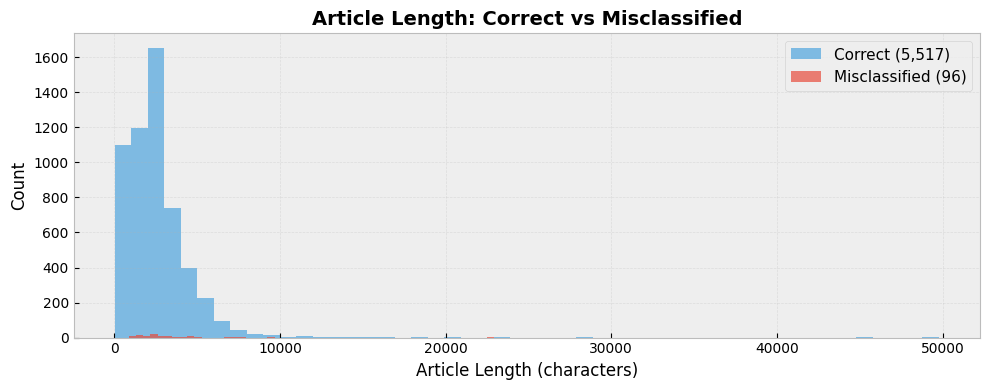

  Avg length (correct)       : 2,550 chars
  Avg length (misclassified) : 3,245 chars


In [25]:
# Analyze misclassified articles — are they shorter on average?
if misclassified_mask.sum() > 0:
    correct_lengths = df.loc[test_indices[~misclassified_mask], 'news'].str.len()
    wrong_lengths   = df.loc[misclassified_idx, 'news'].str.len()

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(correct_lengths, bins=50, alpha=0.6, color='#3498db', label=f'Correct ({len(correct_lengths):,})')
    ax.hist(wrong_lengths, bins=50, alpha=0.7, color='#e74c3c', label=f'Misclassified ({len(wrong_lengths):,})')
    ax.set_xlabel('Article Length (characters)', fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    ax.set_title('Article Length: Correct vs Misclassified', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"  Avg length (correct)       : {correct_lengths.mean():,.0f} chars")
    print(f"  Avg length (misclassified) : {wrong_lengths.mean():,.0f} chars")

## 14. Export Best Model for ProductionRe-fit the vectorizer and model on the **full dataset** for maximum coverage, then serialize for the Flask API.

In [26]:
# Re-fit on full dataset for production deployment
prod_cv = CountVectorizer()
prod_counts = prod_cv.fit_transform(df['news'])

prod_tfidf = TfidfTransformer()
prod_tfidf_matrix = prod_tfidf.fit_transform(prod_counts)

prod_model = LogisticRegression(max_iter=1000)
prod_model.fit(prod_tfidf_matrix, df['label'])

# Save artifacts
EXPORT_DIR = 'models'
os.makedirs(EXPORT_DIR, exist_ok=True)

joblib.dump(prod_model,  os.path.join(EXPORT_DIR, 'model.pkl'))
joblib.dump(prod_cv,     os.path.join(EXPORT_DIR, 'count_vectorizer.pkl'))
joblib.dump(prod_tfidf,  os.path.join(EXPORT_DIR, 'tfidf.pkl'))

print(f"✅ Model and vectorizers exported to '{EXPORT_DIR}/'")
for f in ['model.pkl', 'count_vectorizer.pkl', 'tfidf.pkl']:
    print(f"   • {f:<25} ({os.path.getsize(os.path.join(EXPORT_DIR, f)) / 1024:.0f} KB)")

✅ Model and vectorizers exported to 'models/'
   • model.pkl                 (718 KB)
   • count_vectorizer.pkl      (1300 KB)
   • tfidf.pkl                 (717 KB)
